到目前为止，我们做的所有练习（预测房价、预测生存）都有一个共同点：我们知道标准答案。 这叫监督学习 (Supervised Learning)。

但现实中，很多时候我们没有答案。

例子：你有 100 万个客户的消费数据，你想把他们分成几类人进行精准营销，但你并不知道这几类人叫什么。

这就是：无监督学习 (Unsupervised Learning)。

D:\Anaconda\envs\DL\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


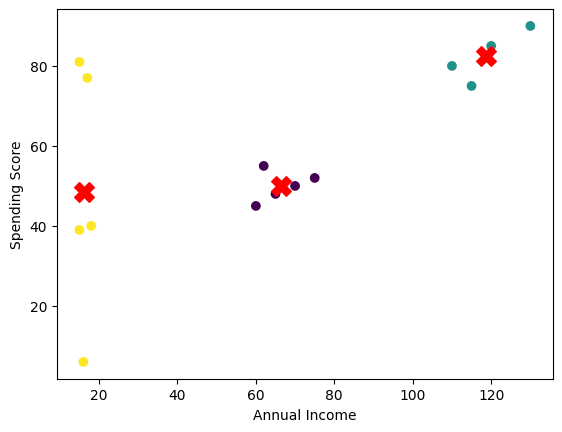

[2 2 2 2 2 0 0 0 0 0 1 1 1 1] [[ 66.4   50.  ]
 [118.75  82.5 ]
 [ 16.2   48.6 ]]
各组特征平均值：
       发帖频率   点赞数
类别              
0    66.40  50.0
1   118.75  82.5
2    16.20  48.6


In [1]:


from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. 模拟数据：[年收入(万元), 消费频率(1-100)]
X = np.array([
    [15, 39], [15, 81], [16, 6], [17, 77], [18, 40], # 穷但爱买 / 穷且省
    [60, 45], [62, 55], [65, 48], [70, 50], [75, 52], # 中产阶级
    [110, 80], [120, 85], [130, 90], [115, 75]       # 土豪组
])

# 2. 实例化：我们要把他们分成 3 类
kmeans = KMeans(n_clusters=3, random_state=42)

# 3. 拟合：注意！无监督学习只有 X，没有 y
kmeans.fit(X)

# 4. 获取结果：每个点属于哪个类别
labels = kmeans.labels_
centers = kmeans.cluster_centers_

# 5. 可视化
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200) # 画出旗子
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

print(labels,centers)

df = pd.DataFrame(X, columns=['发帖频率','点赞数'])
df['类别'] = labels   #kmeans.label_产生的结果

#关键动作：看每一类的平均值
analysis = df.groupby('类别').mean()
print("各组特征平均值：\n",analysis)



## 🎭 今日第二站：降维打击 —— PCA（主成分分析）
在完成“聚类”之后，无监督学习还有另一块极其重要的拼图：降维 (Dimensionality Reduction)。

1. 为什么要“降维”？
想象你正在处理一个极其复杂的项目，每个样本有 100 个特征（维度）。

计算爆炸：维度越多，计算速度越慢，模型越容易乱套（这叫“维数灾难”）。

无法可视化：人类只能理解 2D 或 3D 的图。面对 100 维的数据，我们根本看不出规律。

PCA 的目标： 把一个“胖”数据（特征很多）变成一个“瘦”数据（特征很少），同时尽量保留它原本的“灵魂”（信息量）。

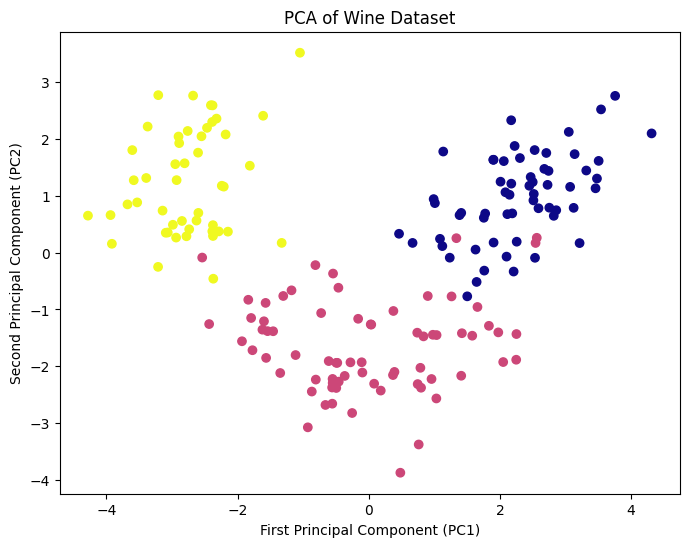

保留的信息占比: 55.41%


In [2]:


from sklearn.decomposition import PCA
from sklearn.datasets import load_wine
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

#1.加载数据
wine = load_wine()
X = wine.data
y = wine.target

#2.标准化
#因为PCA是根据方差来的，如果不标准化，数值大的特征会霸占整个屏幕
X_scaled = StandardScaler().fit_transform(X)

# 3.实例化 PCA：目的是降到2维
pca = PCA(n_components=2)

# 4. 训练并转换
X_pca = pca.fit_transform(X_scaled)

# 5. 可视化
plt.figure(figsize=(8, 6))
# 绘制散点图，颜色代表红酒的种类
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='plasma')
plt.xlabel('First Principal Component (PC1)')
plt.ylabel('Second Principal Component (PC2)')
plt.title('PCA of Wine Dataset')
plt.show()

# 看看这两个新特征解释了多少原始信息
print(f"保留的信息占比: {sum(pca.explained_variance_ratio_):.2%}")

